# ECB Shock Regressions at the Index Level

This notebook constructs quarterly Euro500 market-duration series from firm-level duration measures and tests whether index-level ECB shock sensitivity varies with aggregate duration.

Baseline design:
- firm-level durations are aggregated to market-cap-weighted quarterly market duration
- ECB event dates are matched to the latest available pre-event quarter to avoid look-ahead bias
- Euro500 event-window returns are regressed on monetary policy and information shocks, including interactions with standardized market duration

The exercise complements firm-level panel regressions by asking whether time variation in aggregate market duration helps explain how the Euro500 index reacts to ECB shocks.


## 1. Setup and imports

This section defines placeholder file paths, output locations, and flexible column mappings. The notebook is written so that the main variable names can be adjusted in one place before running the full workflow.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display
from plot_style import COLORS, set_global_plot_style, style_axes, style_legend, style_time_axis

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
set_global_plot_style()

BASE_DIR = Path("/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data")
DATA_DIR = BASE_DIR / "intermediate"

# ------------------------------------------------------------------
# User inputs: defaults follow the existing project notebooks.
# ------------------------------------------------------------------
path_macaulay_duration = DATA_DIR / "EQDuration_Macaulay.parquet"
path_netpayout_duration = DATA_DIR / "EQDuration_Netpayout.parquet"
path_ecb_shocks = DATA_DIR / "shocks_ecb_mpd_me_d.csv"
path_euro500_returns = DATA_DIR / "euro500_index_returns.parquet"
exclude_financials = True

output_dir = Path("/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/index_regressions")
output_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------------
# Column mapping candidates: adjust these lists if your files differ.
# The helper functions take the first matching column.
# ------------------------------------------------------------------
DURATION_COMMON = {
    "date_candidates": ["date", "Date", "as_of_date", "obs_date", "effective_date"],
    "quarter_candidates": ["quarter", "Quarter", "quarter_end", "quarter_date"],
    "firm_candidates": ["firm_id", "FirmID", "gvkey", "isin", "ric", "RIC", "Instrument"],
    "mcap_candidates": ["market_cap", "MarketCap", "mcap", "mcap_eur", "ME", "ff_mcap", "weight_base_mcap"],
    "sector_candidates": ["trbc_sector", "TRBC_Sector", "sector", "Sector", "gics_sector", "GICS_sector_name"],
}

MACAULAY_CONFIG = {
    "duration_candidates": ["duration_macaulay_r125_clean", "duration_macaulay_r125", "duration_macaulay_r10_clean", "duration_macaulay_clean", "duration_macaulay_r10", "duration_macaulay", "macaulay_duration", "MacaulayDuration", "eq_duration_macaulay"],
}

NETPAYOUT_CONFIG = {
    "duration_candidates": ["Duration_NetPayout_trim", "Duration_NetPayout", "Duration_NP_trim", "Duration_NP", "NP_Duration", "duration_np", "netpayout_duration", "duration_netpayout", "NetPayoutDuration", "eq_duration_netpayout"],
}

ECB_CONFIG = {
    "event_date_candidates": ["event_date", "date", "Date", "meeting_date"],
    "shock_mp_candidates": ["ShockMP", "shock_mp", "mp_shock", "monetary_policy_shock", "MP_median", "MP_pm"],
    "shock_info_candidates": ["ShockInfo", "shock_info", "info_shock", "information_shock", "CBI_median", "CBI_pm"],
}

INDEX_CONFIG = {
    "date_candidates": ["date", "Date", "trade_date"],
    "price_candidates": ["price", "Price", "close", "Close", "index_level", "IndexLevel", "PX_LAST"],
    "return_candidates": ["market_return_ffmcap_capped80", "market_return_ffmcap", "market_ret_cap80", "index_return", "return", "Return", "simple_return", "ret", "abnormal_return"],
    "log_return_candidates": ["log_return", "LogReturn", "log_ret"],
}

RESULT_COLUMNS = [
    "model_label",
    "duration_variant",
    "duration_weighting",
    "return_window",
    "duration_column",
    "shock_spec",
    "calendar_controls",
    "cov_type",
    "term",
    "coef",
    "std_err",
    "t_stat",
    "p_value",
    "n_obs",
    "r_squared",
]


In [2]:
def first_existing(df, candidates, required=True, label="column"):
    match = next((col for col in candidates if col in df.columns), None)
    if required and match is None:
        raise KeyError(f"Could not find {label}. Tried: {candidates}")
    return match


def load_table(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing input file: {path}")
    suffix = path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix in {".parquet", ".pq"}:
        return pd.read_parquet(path)
    if suffix in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    raise ValueError(f"Unsupported file type for {path}")


def ensure_datetime(series):
    return pd.to_datetime(series, errors="coerce")


def coerce_quarter_end(df, date_col=None, quarter_col=None):
    if quarter_col and quarter_col in df.columns:
        quarter_raw = df[quarter_col]
        quarter_dt = pd.to_datetime(quarter_raw, errors="coerce")
        if quarter_dt.notna().any():
            return quarter_dt.dt.to_period("Q").dt.to_timestamp("Q")
        quarter_period = pd.PeriodIndex(quarter_raw.astype(str), freq="Q")
        return pd.Series(quarter_period.to_timestamp("Q"), index=df.index)
    if date_col and date_col in df.columns:
        return pd.to_datetime(df[date_col], errors="coerce").dt.to_period("Q").dt.to_timestamp("Q")
    raise KeyError("Need either a date column or a quarter column to construct quarter-end dates.")


def standardize_series(series):
    std = series.std(ddof=0)
    if pd.isna(std) or std == 0:
        return pd.Series(np.nan, index=series.index)
    return (series - series.mean()) / std


def significance_stars(p_value):
    if pd.isna(p_value):
        return ""
    if p_value < 0.01:
        return "***"
    if p_value < 0.05:
        return "**"
    if p_value < 0.10:
        return "*"
    return ""


def format_coef_tstat(coef, t_stat, p_value, decimals=4):
    if pd.isna(coef):
        return ""
    stars = significance_stars(p_value)
    return f"{coef:.{decimals}f}{stars} ({t_stat:.2f})"


def display_df(df, n=10):
    display(df.head(n) if len(df) > n else df)


## 2. Load firm-level duration data

The notebook expects one file for Macaulay duration and one file for Net-Payout duration. Each file should contain at least a firm identifier, a quarter or date variable, a market-cap variable, and the duration measure itself.


In [3]:
def _standardize_reference_for_mcap(df, common_config=DURATION_COMMON):
    ref = df.copy()
    ref_date_col = first_existing(ref, common_config["date_candidates"], required=False, label="reference date")
    ref_quarter_col = first_existing(ref, common_config["quarter_candidates"], required=False, label="reference quarter")
    ref_firm_col = first_existing(ref, common_config["firm_candidates"], required=True, label="reference firm id")
    ref_mcap_col = first_existing(ref, common_config["mcap_candidates"], required=False, label="reference market cap")
    if ref_mcap_col is None:
        return None
    out = ref.rename(columns={ref_firm_col: "firm_id", ref_mcap_col: "market_cap_ref"}).copy()
    out["quarter_end"] = coerce_quarter_end(out, date_col=ref_date_col, quarter_col=ref_quarter_col)
    out["market_cap_ref"] = pd.to_numeric(out["market_cap_ref"], errors="coerce")
    out = out[["firm_id", "quarter_end", "market_cap_ref"]].dropna(subset=["firm_id", "quarter_end", "market_cap_ref"])
    out = out.sort_values(["firm_id", "quarter_end"]).drop_duplicates(subset=["firm_id", "quarter_end"], keep="last")
    return out


def _standardize_reference_for_sector(df, common_config=DURATION_COMMON):
    ref = df.copy()
    ref_date_col = first_existing(ref, common_config["date_candidates"], required=False, label="reference date")
    ref_quarter_col = first_existing(ref, common_config["quarter_candidates"], required=False, label="reference quarter")
    ref_firm_col = first_existing(ref, common_config["firm_candidates"], required=True, label="reference firm id")
    ref_sector_col = first_existing(ref, common_config["sector_candidates"], required=False, label="reference sector")
    if ref_sector_col is None:
        return None
    out = ref.rename(columns={ref_firm_col: "firm_id", ref_sector_col: "sector_name_ref"}).copy()
    out["quarter_end"] = coerce_quarter_end(out, date_col=ref_date_col, quarter_col=ref_quarter_col)
    out["sector_name_ref"] = out["sector_name_ref"].astype("string").str.strip()
    out = out[["firm_id", "quarter_end", "sector_name_ref"]].dropna(subset=["firm_id", "quarter_end"])
    out = out.sort_values(["firm_id", "quarter_end"]).drop_duplicates(subset=["firm_id", "quarter_end"], keep="last")
    return out


def prepare_duration_frame(df, duration_candidates, label, common_config=DURATION_COMMON, mcap_reference=None):
    df = df.copy()
    date_col = first_existing(df, common_config["date_candidates"], required=False, label=f"{label} date column")
    quarter_col = first_existing(df, common_config["quarter_candidates"], required=False, label=f"{label} quarter column")
    firm_col = first_existing(df, common_config["firm_candidates"], required=True, label=f"{label} firm identifier")
    mcap_col = first_existing(df, common_config["mcap_candidates"], required=False, label=f"{label} market cap")
    sector_col = first_existing(df, common_config["sector_candidates"], required=False, label=f"{label} sector")
    duration_col = first_existing(df, duration_candidates, required=True, label=f"{label} duration")

    rename_map = {firm_col: "firm_id", duration_col: "duration_value"}
    if mcap_col is not None:
        rename_map[mcap_col] = "market_cap"
    if sector_col is not None:
        rename_map[sector_col] = "sector_name"
    out = df.rename(columns=rename_map).copy()
    out["quarter_end"] = coerce_quarter_end(out, date_col=date_col, quarter_col=quarter_col)
    if "market_cap" in out.columns:
        out["market_cap"] = pd.to_numeric(out["market_cap"], errors="coerce")
    else:
        out["market_cap"] = np.nan
    if "sector_name" in out.columns:
        out["sector_name"] = out["sector_name"].astype("string").str.strip()
    else:
        out["sector_name"] = pd.Series(pd.NA, index=out.index, dtype="string")
    out["duration_value"] = pd.to_numeric(out["duration_value"], errors="coerce")

    if out["market_cap"].isna().all() and mcap_reference is not None:
        ref = _standardize_reference_for_mcap(mcap_reference, common_config=common_config)
        if ref is not None:
            out = out.merge(ref, on=["firm_id", "quarter_end"], how="left")
            out["market_cap"] = out["market_cap"].fillna(out["market_cap_ref"])
            out = out.drop(columns=["market_cap_ref"])

    if out["sector_name"].isna().all() and mcap_reference is not None:
        ref_sector = _standardize_reference_for_sector(mcap_reference, common_config=common_config)
        if ref_sector is not None:
            out = out.merge(ref_sector, on=["firm_id", "quarter_end"], how="left")
            out["sector_name"] = out["sector_name"].fillna(out["sector_name_ref"])
            out = out.drop(columns=["sector_name_ref"])

    out = out[["quarter_end", "firm_id", "market_cap", "duration_value", "sector_name"]].dropna(subset=["quarter_end", "firm_id", "market_cap"])
    out["duration_label"] = label
    return out.sort_values(["quarter_end", "firm_id"]).reset_index(drop=True)


macaulay_raw = load_table(path_macaulay_duration)
netpayout_raw = load_table(path_netpayout_duration)

macaulay_firm = prepare_duration_frame(
    macaulay_raw,
    MACAULAY_CONFIG["duration_candidates"],
    label="Macaulay",
    mcap_reference=netpayout_raw,
)
netpayout_firm = prepare_duration_frame(
    netpayout_raw,
    NETPAYOUT_CONFIG["duration_candidates"],
    label="NetPayout",
    mcap_reference=macaulay_raw,
)

print("Loaded firm-level duration data.")
print(f"Macaulay rows:   {len(macaulay_firm):,}")
print(f"Net-Payout rows: {len(netpayout_firm):,}")
print(f"Exclude financials in market-duration aggregation: {exclude_financials}")

display_df(macaulay_firm)
display_df(netpayout_firm)


Loaded firm-level duration data.
Macaulay rows:   52,343
Net-Payout rows: 54,000
Exclude financials in market-duration aggregation: True


/var/folders/r2/vtz74sz14fx185wt9m3c781w0000gn/T/ipykernel_55962/92605450.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  quarter_dt = pd.to_datetime(quarter_raw, errors="coerce")
/var/folders/r2/vtz74sz14fx185wt9m3c781w0000gn/T/ipykernel_55962/92605450.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  quarter_dt = pd.to_datetime(quarter_raw, errors="coerce")
/var/folders/r2/vtz74sz14fx185wt9m3c781w0000gn/T/ipykernel_55962/92605450.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  quarter_dt = pd.to_datetime(quarter_raw, errors="coerce")


,quarter_end,firm_id,market_cap,duration_value,sector_name,duration_label
0,1999-03-31,FIRM0000001,142904483.073431,NaN,Consumer Cyclicals,Macaulay
1,1999-03-31,FIRM0000002,352801297.226928,NaN,Industrials,Macaulay
2,1999-03-31,FIRM0000003,608489692.860167,NaN,Industrials,Macaulay
3,1999-03-31,FIRM0000004,6612871012.04691,NaN,Consumer Cyclicals,Macaulay
4,1999-03-31,FIRM0000005,1427532695.65364,NaN,Industrials,Macaulay
5,1999-03-31,FIRM0000006,762862099.088851,NaN,Basic Materials,Macaulay
6,1999-03-31,FIRM0000008,1159667732.63788,NaN,Basic Materials,Macaulay
7,1999-03-31,FIRM0000009,4305243328.21931,NaN,Consumer Cyclicals,Macaulay
8,1999-03-31,FIRM0000011,146556686.382514,NaN,Consumer Cyclicals,Macaulay
9,1999-03-31,FIRM0000012,56081696.794582,NaN,Real Estate,Macaulay


,quarter_end,firm_id,market_cap,duration_value,sector_name,duration_label
0,1999-03-31,FIRM0000001,142904483.073431,NaN,Consumer Cyclicals,NetPayout
1,1999-03-31,FIRM0000002,352801297.226928,NaN,Industrials,NetPayout
2,1999-03-31,FIRM0000003,608489692.860167,NaN,Industrials,NetPayout
3,1999-03-31,FIRM0000004,6612871012.04691,NaN,Consumer Cyclicals,NetPayout
4,1999-03-31,FIRM0000005,1427532695.65364,NaN,Industrials,NetPayout
5,1999-03-31,FIRM0000006,762862099.088851,NaN,Basic Materials,NetPayout
6,1999-03-31,FIRM0000007,35217961.859356,NaN,Consumer Cyclicals,NetPayout
7,1999-03-31,FIRM0000008,1159667732.63788,NaN,Basic Materials,NetPayout
8,1999-03-31,FIRM0000009,4305243328.21931,NaN,Consumer Cyclicals,NetPayout
9,1999-03-31,FIRM0000011,146556686.382514,NaN,Consumer Cyclicals,NetPayout


## 3. Construct quarterly Euro500 market duration series

Market duration is the weighted average of firm-level duration within each quarter. Value-weighting is the baseline because it reflects the aggregate duration exposure of the market portfolio, while equal-weighting is retained as a robustness check.

For each quarter, the notebook also reports:
- the number of contributing firms
- the share of total quarter-level market cap covered by non-missing duration observations
- equal-weighted duration as an alternative aggregation


In [4]:
def exclude_financial_sector_rows(duration_df):
    df = duration_df.copy()
    if not exclude_financials or "sector_name" not in df.columns:
        return df
    sector = df["sector_name"].astype("string").str.strip().str.casefold()
    is_financial = sector.eq("financials") | sector.str.contains("financial", na=False)
    return df.loc[~is_financial | sector.isna()].copy()


def build_market_duration(duration_df, value_col_name, eq_col_name, n_col_name, coverage_col_name):
    df = exclude_financial_sector_rows(duration_df)
    total_mcap = df.groupby("quarter_end", as_index=False)["market_cap"].sum().rename(columns={"market_cap": "total_market_cap"})
    valid = df.dropna(subset=["duration_value"]).copy()
    valid_mcap = valid.groupby("quarter_end", as_index=False)["market_cap"].sum().rename(columns={"market_cap": "covered_market_cap"})
    valid = valid.merge(valid_mcap, on="quarter_end", how="left")
    valid["weight"] = valid["market_cap"] / valid["covered_market_cap"]

    grouped = valid.groupby("quarter_end")
    out = pd.DataFrame({
        "quarter_end": sorted(df["quarter_end"].dropna().unique()),
    })
    out = out.merge(total_mcap, on="quarter_end", how="left")
    out = out.merge(valid_mcap, on="quarter_end", how="left")

    weighted = grouped.apply(lambda x: np.average(x["duration_value"], weights=x["market_cap"]))
    equal_weighted = grouped["duration_value"].mean()
    n_firms = grouped["firm_id"].nunique()

    out[value_col_name] = out["quarter_end"].map(weighted)
    out[eq_col_name] = out["quarter_end"].map(equal_weighted)
    out[n_col_name] = out["quarter_end"].map(n_firms)
    out[coverage_col_name] = out["covered_market_cap"] / out["total_market_cap"]
    out["weights_sum_check"] = out["quarter_end"].map(grouped["weight"].sum())
    return out.sort_values("quarter_end").reset_index(drop=True)


macaulay_firm_agg = exclude_financial_sector_rows(macaulay_firm)
netpayout_firm_agg = exclude_financial_sector_rows(netpayout_firm)

market_duration_macaulay = build_market_duration(
    macaulay_firm_agg,
    value_col_name="market_duration_macaulay",
    eq_col_name="ew_duration_macaulay",
    n_col_name="n_firms_macaulay",
    coverage_col_name="coverage_macaulay",
)

market_duration_netpayout = build_market_duration(
    netpayout_firm_agg,
    value_col_name="market_duration_netpayout",
    eq_col_name="ew_duration_netpayout",
    n_col_name="n_firms_netpayout",
    coverage_col_name="coverage_netpayout",
)

market_duration_quarterly = market_duration_macaulay.merge(
    market_duration_netpayout.drop(columns=["total_market_cap", "covered_market_cap", "weights_sum_check"]),
    on="quarter_end",
    how="outer",
).sort_values("quarter_end").reset_index(drop=True)

for col in ["market_duration_macaulay", "ew_duration_macaulay", "market_duration_netpayout", "ew_duration_netpayout"]:
    market_duration_quarterly[f"{col}_z"] = standardize_series(market_duration_quarterly[col])

weights_check_cols = ["quarter_end", "weights_sum_check"]
print(f"Macaulay rows used after sector filter: {len(macaulay_firm_agg):,}")
print(f"Net-Payout rows used after sector filter: {len(netpayout_firm_agg):,}")
print("Weight-sum diagnostics for valid-duration firms (should be close to 1):")
display_df(market_duration_macaulay[weights_check_cols])
display_df(market_duration_netpayout[weights_check_cols])

market_duration_quarterly.head()


Macaulay rows used after sector filter: 44,505
Net-Payout rows used after sector filter: 45,976
Weight-sum diagnostics for valid-duration firms (should be close to 1):


,quarter_end,weights_sum_check
0,1999-03-31,<NA>
1,1999-06-30,<NA>
2,1999-09-30,<NA>
3,1999-12-31,<NA>
4,2000-03-31,<NA>
5,2000-06-30,<NA>
6,2000-09-30,<NA>
7,2000-12-31,<NA>
8,2001-03-31,<NA>
9,2001-06-30,<NA>


,quarter_end,weights_sum_check
0,1999-03-31,<NA>
1,1999-06-30,<NA>
2,1999-09-30,<NA>
3,1999-12-31,<NA>
4,2000-03-31,1.0
5,2000-06-30,1.0
6,2000-09-30,1.0
7,2000-12-31,1.0
8,2001-03-31,1.0
9,2001-06-30,1.0


,quarter_end,total_market_cap,covered_market_cap,market_duration_macaulay,ew_duration_macaulay,n_firms_macaulay,coverage_macaulay,weights_sum_check,market_duration_netpayout,ew_duration_netpayout,n_firms_netpayout,coverage_netpayout,market_duration_macaulay_z,ew_duration_macaulay_z,market_duration_netpayout_z,ew_duration_netpayout_z
0,1999-03-31,1278199689200.592773,<NA>,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
1,1999-06-30,1533312920736.744873,<NA>,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
2,1999-09-30,1717423729373.384521,<NA>,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
3,1999-12-31,1665590607435.802246,<NA>,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN
4,2000-03-31,2442298381433.524902,<NA>,NaN,NaN,NaN,<NA>,<NA>,24.308291,22.773674,91.0,0.606061,NaN,NaN,2.699393,1.3905


## 4. Load ECB shock event data

ECB event data should contain one row per event date with a monetary policy surprise and an information shock. The notebook keeps the two shock channels separate throughout, because their economic interpretation can differ.


In [5]:
def prepare_ecb_shocks(df, config=ECB_CONFIG):
    df = df.copy()
    event_date_col = first_existing(df, config["event_date_candidates"], required=True, label="ECB event date")
    shock_mp_col = first_existing(df, config["shock_mp_candidates"], required=True, label="ShockMP")
    shock_info_col = first_existing(df, config["shock_info_candidates"], required=True, label="ShockInfo")

    out = df.rename(columns={
        event_date_col: "event_date",
        shock_mp_col: "ShockMP",
        shock_info_col: "ShockInfo",
    }).copy()
    out["event_date"] = pd.to_datetime(out["event_date"], errors="coerce").dt.normalize()
    out["ShockMP"] = pd.to_numeric(out["ShockMP"], errors="coerce")
    out["ShockInfo"] = pd.to_numeric(out["ShockInfo"], errors="coerce")
    out = out[["event_date", "ShockMP", "ShockInfo"]].dropna().drop_duplicates("event_date").sort_values("event_date").reset_index(drop=True)
    out["event_year"] = out["event_date"].dt.year.astype(int)
    out["abs_shock_scale"] = out[["ShockMP", "ShockInfo"]].abs().max(axis=1)
    return out


ecb_shocks = prepare_ecb_shocks(load_table(path_ecb_shocks))
print(f"ECB events loaded: {len(ecb_shocks):,}")
display_df(ecb_shocks)


ECB events loaded: 312


,event_date,ShockMP,ShockInfo,event_year,abs_shock_scale
0,1999-01-07,0.020578,-0.058123,1999,0.058123
1,1999-01-21,0.008569,-0.004988,1999,0.008569
2,1999-02-18,-0.005565,0.005565,1999,0.005565
3,1999-03-04,-0.003596,0.001670,1999,0.003596
4,1999-03-18,-0.002326,0.001568,1999,0.002326
5,1999-04-08,-0.002429,-0.005027,1999,0.005027
6,1999-04-22,-0.004369,0.001721,1999,0.004369
7,1999-05-06,0.014787,-0.008722,1999,0.014787
8,1999-05-20,0.000644,-0.000644,1999,0.000644
9,1999-06-02,-0.002658,-0.004620,1999,0.004620


## 5. Load Euro500 index return data

The notebook accepts either daily prices or daily returns.

Implementation choice:
- if prices are provided, simple returns and log returns are both computed
- event-window regressions use simple returns by default for direct interpretability
- if a return column is already present, it is used as the baseline daily simple return input


In [6]:
def prepare_index_daily(df, config=INDEX_CONFIG):
    df = df.copy()
    date_col = first_existing(df, config["date_candidates"], required=True, label="index date")
    return_col = first_existing(df, config["return_candidates"], required=False, label="index return")
    price_col = first_existing(df, config["price_candidates"], required=False, label="index price")
    log_return_col = first_existing(df, config["log_return_candidates"], required=False, label="index log return")

    out = df.rename(columns={date_col: "date"}).copy()
    out["date"] = pd.to_datetime(out["date"], errors="coerce").dt.normalize()
    out = out.dropna(subset=["date"]).sort_values("date").drop_duplicates(subset=["date"], keep="last").reset_index(drop=True)

    if price_col:
        out["index_price"] = pd.to_numeric(out[price_col], errors="coerce")
        out["simple_return_from_price"] = out["index_price"].pct_change()
        out["log_return_from_price"] = np.log(out["index_price"]).diff()

    if return_col:
        out["simple_return_input"] = pd.to_numeric(out[return_col], errors="coerce")
    elif "simple_return_from_price" in out.columns:
        out["simple_return_input"] = out["simple_return_from_price"]
    else:
        raise KeyError(f"Need an index return column. Tried: {config['return_candidates']} and price fallbacks.")

    if log_return_col:
        out["log_return_input"] = pd.to_numeric(out[log_return_col], errors="coerce")
    elif "log_return_from_price" in out.columns:
        out["log_return_input"] = out["log_return_from_price"]

    out["lead_return_1"] = out["simple_return_input"].shift(-1)
    out["lag_return_1"] = out["simple_return_input"].shift(1)
    return out


index_daily = prepare_index_daily(load_table(path_euro500_returns))
print(f"Index daily observations loaded: {len(index_daily):,}")
display_df(index_daily[[col for col in index_daily.columns if col in ['date', 'index_price', 'simple_return_input', 'log_return_input', 'lead_return_1', 'lag_return_1']]])


Index daily observations loaded: 7,016


,date,simple_return_input,lead_return_1,lag_return_1
0,1999-01-04,0.042915,0.007018,NaN
1,1999-01-05,0.007018,NaN,0.042915
2,1999-01-06,NaN,-0.013601,0.007018
3,1999-01-07,-0.013601,0.001873,NaN
4,1999-01-08,0.001873,-0.009510,-0.013601
5,1999-01-11,-0.009510,-0.018137,0.001873
6,1999-01-12,-0.018137,-0.036189,-0.009510
7,1999-01-13,-0.036189,0.003051,-0.018137
8,1999-01-14,0.003051,0.013920,-0.036189
9,1999-01-15,0.013920,0.015909,0.003051


## 6. Merge shocks, index returns, and market duration

Two alignment steps matter.

First, event returns are assigned using the first available trading day on or after the ECB event date. This avoids dropping events that fall on non-trading days.

Second, market duration is mapped using the latest quarter-end strictly before the event date. This makes the no-look-ahead rule explicit: only information available before the event can enter the regression.


In [7]:
def build_event_return_dataset(events_df, index_df):
    idx = index_df[["date", "simple_return_input", "lead_return_1", "lag_return_1"]].dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
    events = events_df.sort_values("event_date").reset_index(drop=True).copy()

    mapped = pd.merge_asof(
        events,
        idx.rename(columns={"date": "trade_date"}).sort_values("trade_date"),
        left_on="event_date",
        right_on="trade_date",
        direction="forward",
    )

    mapped["R_0"] = mapped["simple_return_input"]
    mapped["R_0_1"] = (1 + mapped["simple_return_input"]) * (1 + mapped["lead_return_1"]) - 1
    mapped["R_m1_1"] = (1 + mapped["lag_return_1"]) * (1 + mapped["simple_return_input"]) * (1 + mapped["lead_return_1"]) - 1
    return mapped


def map_market_duration_to_events(events_df, market_duration_df):
    durations = market_duration_df.sort_values("quarter_end").copy()
    events = events_df.sort_values("event_date").copy()
    events["duration_lookup_date"] = events["event_date"] - pd.Timedelta(days=1)

    mapped = pd.merge_asof(
        events,
        durations,
        left_on="duration_lookup_date",
        right_on="quarter_end",
        direction="backward",
    )
    mapped = mapped.drop(columns=["duration_lookup_date"])
    mapped = mapped.rename(columns={"quarter_end": "matched_quarter"})
    return mapped


event_returns = build_event_return_dataset(ecb_shocks, index_daily)
event_dataset = map_market_duration_to_events(event_returns, market_duration_quarterly)

mapping_diagnostics = event_dataset[[
    "event_date",
    "trade_date",
    "matched_quarter",
    "market_duration_macaulay",
    "market_duration_netpayout",
    "ew_duration_macaulay",
    "ew_duration_netpayout",
]].copy()

print("Event-to-quarter mapping diagnostics:")
display_df(mapping_diagnostics, n=20)


Event-to-quarter mapping diagnostics:


,event_date,trade_date,matched_quarter,market_duration_macaulay,market_duration_netpayout,ew_duration_macaulay,ew_duration_netpayout
0,1999-01-07,1999-01-07,NaT,NaN,NaN,NaN,NaN
1,1999-01-21,1999-01-21,NaT,NaN,NaN,NaN,NaN
2,1999-02-18,1999-02-18,NaT,NaN,NaN,NaN,NaN
3,1999-03-04,1999-03-04,NaT,NaN,NaN,NaN,NaN
4,1999-03-18,1999-03-18,NaT,NaN,NaN,NaN,NaN
5,1999-04-08,1999-04-08,1999-03-31,NaN,NaN,NaN,NaN
6,1999-04-22,1999-04-22,1999-03-31,NaN,NaN,NaN,NaN
7,1999-05-06,1999-05-06,1999-03-31,NaN,NaN,NaN,NaN
8,1999-05-20,1999-05-20,1999-03-31,NaN,NaN,NaN,NaN
9,1999-06-02,1999-06-02,1999-03-31,NaN,NaN,NaN,NaN


## 7. Define regression samples

The main event-level dataset contains one row per ECB event with shocks, return windows, matched market duration measures, and simple calendar controls. The default interaction regressions standardize duration first so that interaction coefficients are easier to compare across duration concepts.


In [8]:
def add_regression_features(df):
    out = df.copy()
    out["year_str"] = out["event_year"].astype(str)
    out["high_duration_macaulay"] = (out["market_duration_macaulay"] >= out["market_duration_macaulay"].median()).astype(float)
    out["high_duration_netpayout"] = (out["market_duration_netpayout"] >= out["market_duration_netpayout"].median()).astype(float)
    out["tiny_shock_cutoff"] = out["abs_shock_scale"].quantile(0.20)
    out["large_shock_event"] = out["abs_shock_scale"] > out["tiny_shock_cutoff"]
    return out


event_dataset = add_regression_features(event_dataset)

main_sample = event_dataset.dropna(subset=[
    "ShockMP",
    "ShockInfo",
    "R_0",
    "R_0_1",
    "market_duration_macaulay_z",
    "market_duration_netpayout_z",
]).copy()

print(f"Main regression sample: {len(main_sample):,} events")
display_df(main_sample[[
    "event_date", "trade_date", "ShockMP", "ShockInfo", "R_0", "R_0_1",
    "market_duration_macaulay", "market_duration_netpayout",
    "market_duration_macaulay_z", "market_duration_netpayout_z"
]])


Main regression sample: 215 events


,event_date,trade_date,ShockMP,ShockInfo,R_0,R_0_1,market_duration_macaulay,market_duration_netpayout,market_duration_macaulay_z,market_duration_netpayout_z
93,2004-01-08,2004-01-08,-0.013157,0.007423,0.013067,0.006924,7.977978,23.026124,-0.897232,0.726852
94,2004-02-05,2004-02-05,-0.001627,-0.006882,-0.001102,0.004153,7.977978,23.026124,-0.897232,0.726852
95,2004-03-04,2004-03-04,0.012367,0.028130,0.004766,0.004543,7.977978,23.026124,-0.897232,0.726852
96,2004-04-01,2004-04-01,0.049621,0.025434,0.008560,0.027687,7.825323,22.277368,-1.003503,-0.425067
97,2004-05-06,2004-05-06,0.017465,-0.006544,-0.018023,-0.020528,7.825323,22.277368,-1.003503,-0.425067
98,2004-06-03,2004-06-03,-0.010604,-0.000144,0.001904,0.011554,7.825323,22.277368,-1.003503,-0.425067
99,2004-07-01,2004-07-01,0.008629,-0.008123,-0.001105,-0.008515,6.846955,22.226179,-1.684595,-0.503819
100,2004-08-05,2004-08-05,-0.001396,0.002177,0.000551,-0.023374,6.846955,22.226179,-1.684595,-0.503819
101,2004-09-02,2004-09-02,0.011409,0.001039,0.005889,0.010831,6.846955,22.226179,-1.684595,-0.503819
102,2004-10-07,2004-10-07,-0.004113,-0.008010,-0.000928,-0.006869,7.497441,22.244517,-1.231759,-0.475607


## 8. Estimate main regressions

Baseline specification:

\[
R_t = a + b_1 ShockMP_t + b_2 ShockInfo_t + b_3 (ShockMP_t \\times D_t) + b_4 (ShockInfo_t \\times D_t) + u_t
\]

Expected signs:
- `ShockMP × Duration`: typically negative if a positive monetary policy surprise is a tightening shock that hurts long-duration markets more strongly
- `ShockInfo × Duration`: potentially positive if long-duration or growth-like markets benefit more from improved macroeconomic news


In [9]:
def build_design_matrix(df, y_col, duration_col, include_both_shocks=True, only_shock=None, calendar_controls=False):
    cols = [y_col, duration_col, "ShockMP", "ShockInfo", "event_year"]
    work = df[cols].dropna().copy()
    work["mp_x_d"] = work["ShockMP"] * work[duration_col]
    work["info_x_d"] = work["ShockInfo"] * work[duration_col]

    x_cols = []
    if include_both_shocks:
        x_cols.extend(["ShockMP", "ShockInfo", "mp_x_d", "info_x_d"])
    elif only_shock == "ShockMP":
        x_cols.extend(["ShockMP", "mp_x_d"])
    elif only_shock == "ShockInfo":
        x_cols.extend(["ShockInfo", "info_x_d"])
    else:
        raise ValueError("Invalid shock specification.")

    X = work[x_cols].copy()
    if calendar_controls:
        year_dummies = pd.get_dummies(work["event_year"].astype(int), prefix="year", drop_first=True, dtype=float)
        X = pd.concat([X, year_dummies], axis=1)
    X = sm.add_constant(X, has_constant="add")
    y = work[y_col].astype(float)
    return work, X.astype(float), y


def fit_ols(y, X, cov_type="HC1", cov_lags=1):
    model = sm.OLS(y, X, missing="drop")
    if cov_type.upper() == "HAC":
        return model.fit(cov_type="HAC", cov_kwds={"maxlags": cov_lags})
    return model.fit(cov_type=cov_type)


def collect_terms(result, metadata, requested_terms):
    rows = []
    for term in requested_terms:
        rows.append({
            **metadata,
            "term": term,
            "coef": result.params.get(term, np.nan),
            "std_err": result.bse.get(term, np.nan),
            "t_stat": result.tvalues.get(term, np.nan),
            "p_value": result.pvalues.get(term, np.nan),
            "n_obs": int(result.nobs),
            "r_squared": result.rsquared,
        })
    return rows


def run_model_suite(df, duration_col, duration_variant, duration_weighting, return_window, cov_type="HC1"):
    results = []
    requested_terms = ["ShockMP", "ShockInfo", "mp_x_d", "info_x_d"]

    # Model 1: baseline interaction model with standardized duration.
    work, X, y = build_design_matrix(df, y_col=return_window, duration_col=duration_col, include_both_shocks=True, calendar_controls=False)
    res = fit_ols(y, X, cov_type=cov_type)
    results.extend(collect_terms(res, {
        "model_label": "Model 1",
        "duration_variant": duration_variant,
        "duration_weighting": duration_weighting,
        "return_window": return_window,
        "duration_column": duration_col,
        "shock_spec": "Both shocks",
        "calendar_controls": False,
        "cov_type": cov_type,
    }, requested_terms))

    # Model 2: add year dummies as calendar controls.
    work, X, y = build_design_matrix(df, y_col=return_window, duration_col=duration_col, include_both_shocks=True, calendar_controls=True)
    res = fit_ols(y, X, cov_type=cov_type)
    results.extend(collect_terms(res, {
        "model_label": "Model 2",
        "duration_variant": duration_variant,
        "duration_weighting": duration_weighting,
        "return_window": return_window,
        "duration_column": duration_col,
        "shock_spec": "Both shocks + year FE",
        "calendar_controls": True,
        "cov_type": cov_type,
    }, requested_terms))

    # Model 3: equal-weight duration or alternative duration specification fed into duration_col.
    # This function is reused for both value-weighted and equal-weighted calls.

    # Model 4A: MP-only interaction.
    work, X, y = build_design_matrix(df, y_col=return_window, duration_col=duration_col, include_both_shocks=False, only_shock="ShockMP", calendar_controls=False)
    res = fit_ols(y, X, cov_type=cov_type)
    results.extend(collect_terms(res, {
        "model_label": "Model 4A",
        "duration_variant": duration_variant,
        "duration_weighting": duration_weighting,
        "return_window": return_window,
        "duration_column": duration_col,
        "shock_spec": "ShockMP only",
        "calendar_controls": False,
        "cov_type": cov_type,
    }, ["ShockMP", "mp_x_d"]))

    # Model 4B: Info-only interaction.
    work, X, y = build_design_matrix(df, y_col=return_window, duration_col=duration_col, include_both_shocks=False, only_shock="ShockInfo", calendar_controls=False)
    res = fit_ols(y, X, cov_type=cov_type)
    results.extend(collect_terms(res, {
        "model_label": "Model 4B",
        "duration_variant": duration_variant,
        "duration_weighting": duration_weighting,
        "return_window": return_window,
        "duration_column": duration_col,
        "shock_spec": "ShockInfo only",
        "calendar_controls": False,
        "cov_type": cov_type,
    }, ["ShockInfo", "info_x_d"]))

    return results


def run_all_main_regressions(df, cov_type="HC1"):
    result_rows = []
    specs = [
        ("market_duration_macaulay_z", "Macaulay", "value_weighted"),
        ("market_duration_netpayout_z", "Net-Payout", "value_weighted"),
        ("ew_duration_macaulay_z", "Macaulay", "equal_weighted"),
        ("ew_duration_netpayout_z", "Net-Payout", "equal_weighted"),
    ]
    for duration_col, duration_variant, duration_weighting in specs:
        for return_window in ["R_0", "R_0_1"]:
            subset = df.dropna(subset=[duration_col, return_window, "ShockMP", "ShockInfo"]).copy()
            result_rows.extend(
                run_model_suite(
                    subset,
                    duration_col=duration_col,
                    duration_variant=duration_variant,
                    duration_weighting=duration_weighting,
                    return_window=return_window,
                    cov_type=cov_type,
                )
            )
    return pd.DataFrame(result_rows)


results_main = run_all_main_regressions(main_sample, cov_type="HC1")
results_main = results_main[RESULT_COLUMNS].sort_values(["duration_weighting", "duration_variant", "return_window", "model_label", "term"]).reset_index(drop=True)

print("Collected compact regression output rows:")
display_df(results_main, n=20)


Collected compact regression output rows:


,model_label,duration_variant,duration_weighting,return_window,duration_column,shock_spec,calendar_controls,cov_type,term,coef,std_err,t_stat,p_value,n_obs,r_squared
0,Model 1,Macaulay,equal_weighted,R_0,ew_duration_macaulay_z,Both shocks,False,HC1,ShockInfo,0.184508,0.030683,6.013329,1.817513e-09,215,0.359410
1,Model 1,Macaulay,equal_weighted,R_0,ew_duration_macaulay_z,Both shocks,False,HC1,ShockMP,-0.189666,0.061168,-3.100731,1.930438e-03,215,0.359410
2,Model 1,Macaulay,equal_weighted,R_0,ew_duration_macaulay_z,Both shocks,False,HC1,info_x_d,-0.000691,0.041785,-0.016548,9.867971e-01,215,0.359410
3,Model 1,Macaulay,equal_weighted,R_0,ew_duration_macaulay_z,Both shocks,False,HC1,mp_x_d,-0.031068,0.070639,-0.439816,6.600704e-01,215,0.359410
4,Model 2,Macaulay,equal_weighted,R_0,ew_duration_macaulay_z,Both shocks + year FE,True,HC1,ShockInfo,0.182454,0.032672,5.584394,2.345169e-08,215,0.452863
5,Model 2,Macaulay,equal_weighted,R_0,ew_duration_macaulay_z,Both shocks + year FE,True,HC1,ShockMP,-0.174547,0.054163,-3.222601,1.270324e-03,215,0.452863
6,Model 2,Macaulay,equal_weighted,R_0,ew_duration_macaulay_z,Both shocks + year FE,True,HC1,info_x_d,-0.002991,0.044520,-0.067190,9.464306e-01,215,0.452863
7,Model 2,Macaulay,equal_weighted,R_0,ew_duration_macaulay_z,Both shocks + year FE,True,HC1,mp_x_d,-0.030148,0.064163,-0.469869,6.384487e-01,215,0.452863
8,Model 4A,Macaulay,equal_weighted,R_0,ew_duration_macaulay_z,ShockMP only,False,HC1,ShockMP,-0.209964,0.069314,-3.029154,2.452394e-03,215,0.237851
9,Model 4A,Macaulay,equal_weighted,R_0,ew_duration_macaulay_z,ShockMP only,False,HC1,mp_x_d,-0.065818,0.072108,-0.912768,3.613647e-01,215,0.237851


## 9. Robustness regressions

The robustness section covers:
- equal-weighted market duration instead of value-weighted duration
- alternative return window (`R_0` versus `R_0_1`)
- raw duration instead of z-scored duration
- exclusion of events with very small absolute shocks
- optional high-duration versus low-duration splits
- HAC / Newey-West inference as an additional robustness check


In [10]:
def run_raw_duration_models(df, cov_type="HC1"):
    rows = []
    specs = [
        ("market_duration_macaulay", "Macaulay", "value_weighted_raw"),
        ("market_duration_netpayout", "Net-Payout", "value_weighted_raw"),
    ]
    for duration_col, duration_variant, duration_weighting in specs:
        for return_window in ["R_0", "R_0_1"]:
            subset = df.dropna(subset=[duration_col, return_window, "ShockMP", "ShockInfo"]).copy()
            rows.extend(run_model_suite(subset, duration_col, duration_variant, duration_weighting, return_window, cov_type=cov_type))
    return pd.DataFrame(rows)


def run_large_shock_models(df, cov_type="HC1"):
    filtered = df[df["large_shock_event"]].copy()
    out = run_all_main_regressions(filtered, cov_type=cov_type)
    out["model_label"] = out["model_label"] + " | large shocks"
    return out


def run_hac_models(df, maxlags=1):
    rows = []
    specs = [
        ("market_duration_macaulay_z", "Macaulay", "value_weighted"),
        ("market_duration_netpayout_z", "Net-Payout", "value_weighted"),
    ]
    for duration_col, duration_variant, duration_weighting in specs:
        for return_window in ["R_0", "R_0_1"]:
            subset = df.dropna(subset=[duration_col, return_window, "ShockMP", "ShockInfo"]).copy()
            rows.extend(run_model_suite(subset, duration_col, duration_variant, duration_weighting, return_window, cov_type="HAC"))
    return pd.DataFrame(rows)


def high_low_duration_split(df, duration_col, duration_variant, return_window="R_0_1"):
    subset = df.dropna(subset=[duration_col, return_window, "ShockMP", "ShockInfo"]).copy()
    median_value = subset[duration_col].median()
    subset["duration_group"] = np.where(subset[duration_col] >= median_value, "High duration", "Low duration")

    rows = []
    for group_name, part in subset.groupby("duration_group"):
        work, X, y = build_design_matrix(part, y_col=return_window, duration_col=duration_col, include_both_shocks=False, only_shock="ShockMP", calendar_controls=False)
        res = fit_ols(y, X, cov_type="HC1")
        rows.append({
            "duration_variant": duration_variant,
            "return_window": return_window,
            "group": group_name,
            "coef_ShockMP": res.params.get("ShockMP", np.nan),
            "t_ShockMP": res.tvalues.get("ShockMP", np.nan),
            "coef_ShockMP_x_D": res.params.get("mp_x_d", np.nan),
            "t_ShockMP_x_D": res.tvalues.get("mp_x_d", np.nan),
            "n_obs": int(res.nobs),
        })
    return pd.DataFrame(rows)


results_raw_duration = run_raw_duration_models(main_sample, cov_type="HC1")
results_large_shocks = run_large_shock_models(main_sample, cov_type="HC1")
results_hac = run_hac_models(main_sample, maxlags=1)

split_macaulay = high_low_duration_split(main_sample, "market_duration_macaulay_z", "Macaulay")
split_netpayout = high_low_duration_split(main_sample, "market_duration_netpayout_z", "Net-Payout")
duration_split_table = pd.concat([split_macaulay, split_netpayout], ignore_index=True)

print("High-vs-low duration split diagnostics:")
display_df(duration_split_table, n=20)


High-vs-low duration split diagnostics:


,duration_variant,return_window,group,coef_ShockMP,t_ShockMP,coef_ShockMP_x_D,t_ShockMP_x_D,n_obs
0,Macaulay,R_0_1,High duration,-0.158663,-3.125422,-0.162224,-1.511288,110
1,Macaulay,R_0_1,Low duration,0.154580,0.748391,0.201952,1.194819,105
2,Net-Payout,R_0_1,High duration,-0.286360,-3.678884,0.072708,0.638761,108
3,Net-Payout,R_0_1,Low duration,-0.359983,-2.908003,-0.294346,-2.029366,107


## 10. Output tables

The notebook builds compact tables rather than printing full `statsmodels` summaries. This keeps the regression output thesis-friendly and easy to compare across return windows and duration concepts.


In [11]:
def pivot_main_table(results_df, weighting_filter, model_label="Model 1"):
    subset = results_df[(results_df["duration_weighting"] == weighting_filter) & (results_df["model_label"] == model_label)].copy()
    if subset.empty:
        return pd.DataFrame()

    base = subset[["duration_variant", "return_window", "n_obs", "r_squared"]].drop_duplicates()
    for source_term, col_name in [
        ("ShockMP", "coef(ShockMP)"),
        ("mp_x_d", "coef(ShockMP x D)"),
        ("ShockInfo", "coef(ShockInfo)"),
        ("info_x_d", "coef(ShockInfo x D)"),
    ]:
        term_slice = subset[subset["term"] == source_term][["duration_variant", "return_window", "coef", "t_stat", "p_value"]].copy()
        rename_map = {"coef": col_name}
        if source_term == "mp_x_d":
            rename_map.update({"t_stat": "t-stat MP x D", "p_value": "p-value MP x D"})
        if source_term == "info_x_d":
            rename_map.update({"t_stat": "t-stat Info x D", "p_value": "p-value Info x D"})
        term_slice = term_slice.rename(columns=rename_map)
        base = base.merge(term_slice, on=["duration_variant", "return_window"], how="left")

    return base.rename(columns={
        "duration_variant": "Duration measure",
        "return_window": "Return window",
        "n_obs": "N",
        "r_squared": "R2",
    }).sort_values(["Duration measure", "Return window"]).reset_index(drop=True)


def build_reader_table(results_df, weighting_filter, model_label="Model 1"):
    subset = results_df[(results_df["duration_weighting"] == weighting_filter) & (results_df["model_label"] == model_label)].copy()
    if subset.empty:
        return pd.DataFrame()
    subset["formatted"] = subset.apply(lambda row: format_coef_tstat(row["coef"], row["t_stat"], row["p_value"]), axis=1)
    reader = subset.pivot_table(
        index=["duration_variant", "return_window"],
        columns="term",
        values="formatted",
        aggfunc="first",
    ).reset_index()
    return reader.rename(columns={
        "duration_variant": "Duration measure",
        "return_window": "Return window",
        "ShockMP": "ShockMP",
        "mp_x_d": "ShockMP x D",
        "ShockInfo": "ShockInfo",
        "info_x_d": "ShockInfo x D",
    }).sort_values(["Duration measure", "Return window"]).reset_index(drop=True)


TABLE_1 = pivot_main_table(results_main, weighting_filter="value_weighted", model_label="Model 1")
TABLE_2 = pivot_main_table(results_main, weighting_filter="equal_weighted", model_label="Model 1")
TABLE_3 = build_reader_table(results_main, weighting_filter="value_weighted", model_label="Model 1")

print("TABLE 1: Main index regressions using value-weighted duration")
display(TABLE_1)
print("TABLE 2: Equal-weighted duration robustness")
display(TABLE_2)
print("TABLE 3: Reader table with compact coefficient formatting")
display(TABLE_3)


TABLE 1: Main index regressions using value-weighted duration


,Duration measure,Return window,N,R2,coef(ShockMP),t_stat_x,p_value_x,coef(ShockMP x D),t-stat MP x D,p-value MP x D,coef(ShockInfo),t_stat_y,p_value_y,coef(ShockInfo x D),t-stat Info x D,p-value Info x D
0,Macaulay,R_0,215,0.365040,-0.187611,-3.219626,0.001284,-0.046792,-0.659660,0.509472,0.184800,6.136051,8.459809e-10,0.006559,0.169818,0.865154
1,Macaulay,R_0_1,215,0.266286,-0.179631,-3.561188,0.000369,-0.037442,-0.635025,0.525412,0.213177,4.949315,7.447529e-07,-0.000502,-0.011111,0.991135
2,Net-Payout,R_0,215,0.360883,-0.195014,-3.111115,0.001864,-0.035817,-0.907839,0.363963,0.183182,4.378661,1.194105e-05,-0.027804,-0.934693,0.349946
3,Net-Payout,R_0_1,215,0.281966,-0.210342,-4.000140,0.000063,-0.094708,-1.720771,0.085292,0.215728,5.073023,3.915461e-07,-0.016758,-0.413932,0.678924


TABLE 2: Equal-weighted duration robustness


,Duration measure,Return window,N,R2,coef(ShockMP),t_stat_x,p_value_x,coef(ShockMP x D),t-stat MP x D,p-value MP x D,coef(ShockInfo),t_stat_y,p_value_y,coef(ShockInfo x D),t-stat Info x D,p-value Info x D
0,Macaulay,R_0,215,0.359410,-0.189666,-3.100731,0.001930,-0.031068,-0.439816,0.660070,0.184508,6.013329,1.817513e-09,-0.000691,-0.016548,0.986797
1,Macaulay,R_0_1,215,0.266789,-0.179329,-3.546960,0.000390,-0.034390,-0.601755,0.547337,0.218957,4.904761,9.354114e-07,0.013466,0.290780,0.771220
2,Net-Payout,R_0,215,0.363754,-0.182147,-3.034481,0.002409,-0.007790,-0.171379,0.863926,0.188617,4.457553,8.290070e-06,-0.047651,-1.525221,0.127204
3,Net-Payout,R_0_1,215,0.278549,-0.181105,-3.403534,0.000665,-0.067395,-1.324603,0.185303,0.217914,4.871855,1.105552e-06,-0.036801,-1.013213,0.310959


TABLE 3: Reader table with compact coefficient formatting


term,Duration measure,Return window,ShockInfo,ShockMP,ShockInfo x D,ShockMP x D
0,Macaulay,R_0,0.1848*** (6.14),-0.1876*** (-3.22),0.0066 (0.17),-0.0468 (-0.66)
1,Macaulay,R_0_1,0.2132*** (4.95),-0.1796*** (-3.56),-0.0005 (-0.01),-0.0374 (-0.64)
2,Net-Payout,R_0,0.1832*** (4.38),-0.1950*** (-3.11),-0.0278 (-0.93),-0.0358 (-0.91)
3,Net-Payout,R_0_1,0.2157*** (5.07),-0.2103*** (-4.00),-0.0168 (-0.41),-0.0947* (-1.72)


## 11. Plots

The plots focus on interpretation rather than styling. The main visual goal is to compare the two market-duration series and summarize how the interaction coefficients behave across specifications.


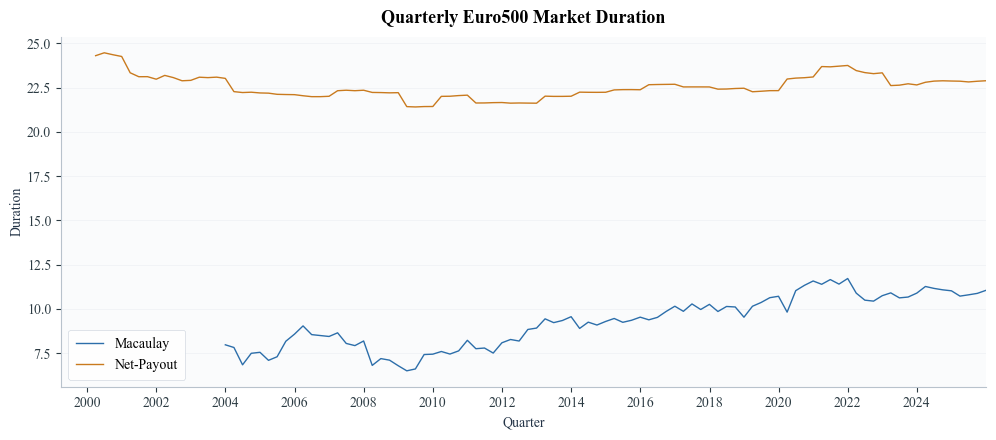

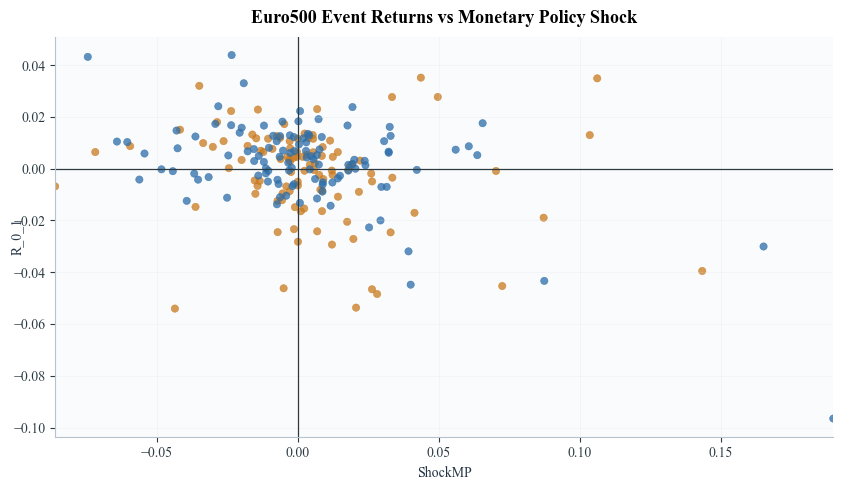

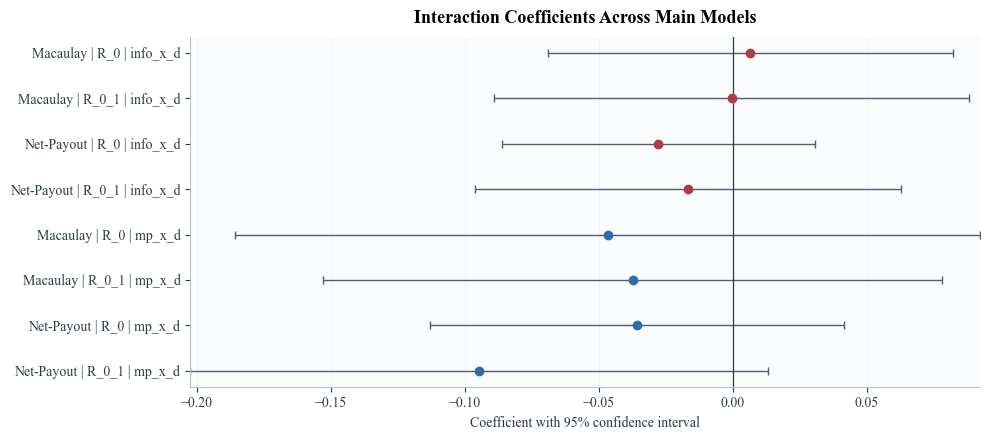

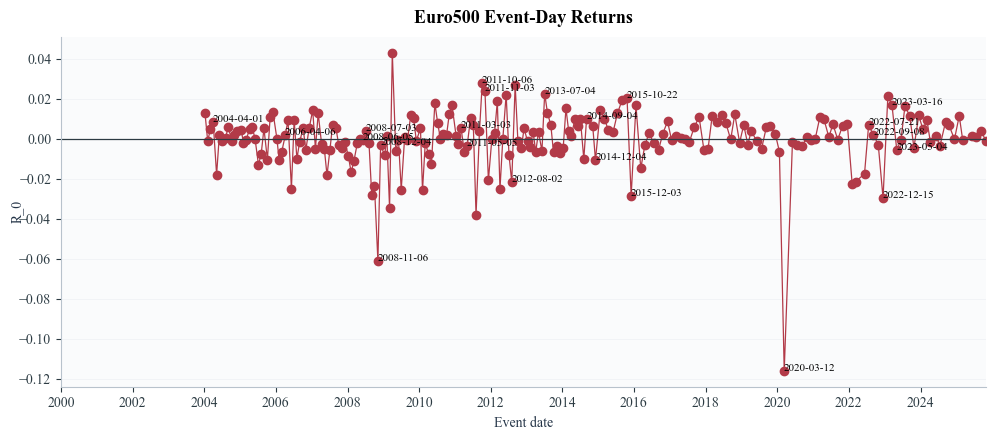

In [12]:
def coefficient_plot_data(results_df):
    subset = results_df[(results_df["model_label"] == "Model 1") & (results_df["duration_weighting"] == "value_weighted")].copy()
    subset = subset[subset["term"].isin(["mp_x_d", "info_x_d"])].copy()
    subset["label"] = subset["duration_variant"] + " | " + subset["return_window"] + " | " + subset["term"]
    subset["ci_low"] = subset["coef"] - 1.96 * subset["std_err"]
    subset["ci_high"] = subset["coef"] + 1.96 * subset["std_err"]
    return subset.sort_values(["term", "duration_variant", "return_window"]).reset_index(drop=True)


fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(
    market_duration_quarterly["quarter_end"],
    market_duration_quarterly["market_duration_macaulay"],
    label="Macaulay",
    color=COLORS["blue"],
)
ax.plot(
    market_duration_quarterly["quarter_end"],
    market_duration_quarterly["market_duration_netpayout"],
    label="Net-Payout",
    color=COLORS["orange"],
)
ax.set_title("Quarterly Euro500 Market Duration")
ax.set_xlabel("Quarter")
ax.set_ylabel("Duration")
style_axes(ax, grid_axis="y", grid_alpha=0.25)
style_time_axis(
    ax,
    x_min=market_duration_quarterly["quarter_end"].min(),
    x_max=market_duration_quarterly["quarter_end"].max(),
    x_ticks=market_duration_quarterly["quarter_end"],
    date_fmt="%Y",
)
style_legend(ax, loc="best")
fig.tight_layout()
fig.savefig(output_dir / "plot_market_duration_timeseries.png", dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 5))
scatter_df = main_sample.dropna(subset=["ShockMP", "R_0_1", "market_duration_macaulay_z"]).copy()
colors = np.where(
    scatter_df["market_duration_macaulay_z"] >= scatter_df["market_duration_macaulay_z"].median(),
    COLORS["blue"],
    COLORS["orange"],
)
ax.scatter(scatter_df["ShockMP"], scatter_df["R_0_1"], c=colors, alpha=0.75, s=28)
ax.axhline(0, color=COLORS["reference"], linewidth=0.9)
ax.axvline(0, color=COLORS["reference"], linewidth=0.9)
ax.set_title("Euro500 Event Returns vs Monetary Policy Shock")
ax.set_xlabel("ShockMP")
ax.set_ylabel("R_0_1")
style_axes(ax, grid_axis="both", grid_alpha=0.22)
fig.tight_layout()
fig.savefig(output_dir / "plot_scatter_shockmp_r01.png", dpi=200, bbox_inches="tight")
plt.show()

coef_plot_df = coefficient_plot_data(results_main)
fig, ax = plt.subplots(figsize=(10, max(4.5, 0.5 * len(coef_plot_df))))
y_pos = np.arange(len(coef_plot_df))
coef_colors = np.where(coef_plot_df["term"].eq("mp_x_d"), COLORS["blue"], COLORS["accent"])
for i, (_, row) in enumerate(coef_plot_df.iterrows()):
    ax.errorbar(
        row["coef"],
        i,
        xerr=1.96 * row["std_err"],
        fmt="o",
        color=coef_colors[i],
        ecolor=COLORS["neutral"],
        capsize=3,
    )
ax.axvline(0, color=COLORS["reference"], linewidth=0.9)
ax.set_yticks(y_pos)
ax.set_yticklabels(coef_plot_df["label"])
ax.invert_yaxis()
ax.set_title("Interaction Coefficients Across Main Models")
ax.set_xlabel("Coefficient with 95% confidence interval")
style_axes(ax, grid_axis="x", grid_alpha=0.25)
fig.tight_layout()
fig.savefig(output_dir / "plot_interaction_coefficients.png", dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(main_sample["event_date"], main_sample["R_0"], marker="o", linestyle="-", linewidth=0.9, color=COLORS["accent"])
shock_cutoff = main_sample["ShockMP"].abs().quantile(0.9)
for _, row in main_sample.iterrows():
    if abs(row["ShockMP"]) >= shock_cutoff:
        ax.annotate(row["event_date"].strftime("%Y-%m-%d"), (row["event_date"], row["R_0"]), fontsize=8)
ax.axhline(0, color=COLORS["reference"], linewidth=0.9)
ax.set_title("Euro500 Event-Day Returns")
ax.set_xlabel("Event date")
ax.set_ylabel("R_0")
style_axes(ax, grid_axis="y", grid_alpha=0.25)
style_time_axis(
    ax,
    x_min=main_sample["event_date"].min(),
    x_max=main_sample["event_date"].max(),
    x_ticks=main_sample["event_date"],
    date_fmt="%Y",
)
fig.tight_layout()
fig.savefig(output_dir / "plot_event_returns_over_time.png", dpi=200, bbox_inches="tight")
plt.show()


## 12. Interpretation notes

This index-level exercise complements firm-level regressions by shifting the focus from cross-sectional heterogeneity to time variation in aggregate market exposure.

Key interpretation points:
- a negative `ShockMP × Duration` coefficient implies that tighter-than-expected ECB policy news hurts the index more when aggregate market duration is high
- a positive `ShockInfo × Duration` coefficient would be consistent with long-duration markets reacting more favorably to information shocks that improve expected growth or earnings prospects
- value-weighted market duration is the baseline because it measures the duration exposure of the market portfolio rather than the average firm
- the strict pre-event quarter matching prevents look-ahead bias and makes the timing assumption transparent


## 12A. Additional Identification Checks

The next sections strengthen the market-level duration analysis in three ways. First, quarterly market duration is expanded to monthly frequency to create more event-level variation. Second, the weak linear interaction design is complemented with a high-versus-low duration regime split. Third, the same baseline and regime specifications are re-estimated for large-shock subsamples where identification is strongest.


### Monthly Market Duration

Quarterly Euro500 duration is repeated to the three month-ends within the same calendar quarter. ECB events are then matched to the nearest previous month-end instead of the nearest previous quarter-end. This preserves the existing quarterly series while creating a denser event-level classification variable.


In [ ]:
def build_monthly_market_duration(duration_df):
    monthly_rows = []
    for _, row in duration_df.sort_values("quarter_end").iterrows():
        quarter = row["quarter_end"].to_period("Q")
        months = pd.period_range(quarter.asfreq("M", how="start"), quarter.asfreq("M", how="end"), freq="M")
        for month in months:
            monthly_rows.append({
                "month_end": month.to_timestamp(how="end").normalize(),
                "quarter_end_source": row["quarter_end"],
                "market_duration_macaulay_monthly": row["market_duration_macaulay"],
                "market_duration_netpayout_monthly": row["market_duration_netpayout"],
            })
    monthly = pd.DataFrame(monthly_rows).sort_values("month_end").drop_duplicates("month_end", keep="last").reset_index(drop=True)
    return monthly


def map_monthly_market_duration_to_events(events_df, monthly_duration_df):
    durations = monthly_duration_df.sort_values("month_end").copy()
    events = events_df.sort_values("event_date").copy()
    events["duration_lookup_date"] = events["event_date"] - pd.Timedelta(days=1)

    mapped = pd.merge_asof(
        events,
        durations,
        left_on="duration_lookup_date",
        right_on="month_end",
        direction="backward",
    )
    mapped = mapped.drop(columns=["duration_lookup_date"])
    mapped = mapped.rename(columns={
        "month_end": "matched_month",
        "market_duration_macaulay_monthly": "D_macaulay_monthly_event",
        "market_duration_netpayout_monthly": "D_netpayout_monthly_event",
    })
    return mapped


market_duration_monthly = build_monthly_market_duration(market_duration_quarterly)
market_duration_macaulay_monthly = market_duration_monthly[["month_end", "market_duration_macaulay_monthly"]].copy()
market_duration_netpayout_monthly = market_duration_monthly[["month_end", "market_duration_netpayout_monthly"]].copy()
event_dataset_monthly = map_monthly_market_duration_to_events(event_dataset, market_duration_monthly)
D_macaulay_monthly_event = event_dataset_monthly["D_macaulay_monthly_event"].copy()
D_netpayout_monthly_event = event_dataset_monthly["D_netpayout_monthly_event"].copy()

monthly_mapping_diagnostics = event_dataset_monthly[[
    "event_date",
    "matched_quarter",
    "matched_month",
    "market_duration_macaulay",
    "market_duration_netpayout",
    "D_macaulay_monthly_event",
    "D_netpayout_monthly_event",
]].copy()

duration_variation_comparison = pd.DataFrame({
    "duration_measure": ["Macaulay", "Net-Payout"],
    "quarterly_std": [
        market_duration_quarterly["market_duration_macaulay"].std(),
        market_duration_quarterly["market_duration_netpayout"].std(),
    ],
    "monthly_std": [
        market_duration_monthly["market_duration_macaulay_monthly"].std(),
        market_duration_monthly["market_duration_netpayout_monthly"].std(),
    ],
    "quarterly_unique_series": [
        market_duration_quarterly["market_duration_macaulay"].nunique(),
        market_duration_quarterly["market_duration_netpayout"].nunique(),
    ],
    "monthly_unique_series": [
        market_duration_monthly["market_duration_macaulay_monthly"].nunique(),
        market_duration_monthly["market_duration_netpayout_monthly"].nunique(),
    ],
    "quarterly_unique_event_values": [
        event_dataset_monthly["market_duration_macaulay"].nunique(),
        event_dataset_monthly["market_duration_netpayout"].nunique(),
    ],
    "monthly_unique_event_values": [
        event_dataset_monthly["D_macaulay_monthly_event"].nunique(),
        event_dataset_monthly["D_netpayout_monthly_event"].nunique(),
    ],
    "quarterly_unique_match_points": [
        event_dataset_monthly["matched_quarter"].nunique(),
        event_dataset_monthly["matched_quarter"].nunique(),
    ],
    "monthly_unique_match_points": [
        event_dataset_monthly["matched_month"].nunique(),
        event_dataset_monthly["matched_month"].nunique(),
    ],
})
duration_variation_comparison["event_variation_gain"] = duration_variation_comparison["monthly_unique_event_values"] - duration_variation_comparison["quarterly_unique_event_values"]
duration_variation_comparison["match_point_gain"] = duration_variation_comparison["monthly_unique_match_points"] - duration_variation_comparison["quarterly_unique_match_points"]
monthly_duration_correlation = market_duration_monthly[["market_duration_macaulay_monthly", "market_duration_netpayout_monthly"]].corr()

print("Monthly event mapping diagnostics:")
display_df(monthly_mapping_diagnostics, n=20)
print("Quarterly vs monthly duration diagnostics:")
display(duration_variation_comparison)
if (duration_variation_comparison["event_variation_gain"] <= 0).all():
    print("Distinct raw duration values stay tight in this sample, but monthly matching still increases the number of event match points.")
print("Correlation between monthly duration concepts:")
display(monthly_duration_correlation)


### High vs Low Duration Regimes

Instead of relying only on linear interactions, the sample is split at the median monthly market duration. This converts a weak slope-identification problem into a direct comparison of high-duration and low-duration market states.


In [ ]:
analysis_sample = event_dataset_monthly.dropna(subset=[
    "ShockMP",
    "ShockInfo",
    "R_0_1",
    "D_macaulay_monthly_event",
    "D_netpayout_monthly_event",
]).copy()
analysis_sample["abs_ShockMP"] = analysis_sample["ShockMP"].abs()
analysis_sample["abs_ShockInfo"] = analysis_sample["ShockInfo"].abs()


def fit_baseline_market_regression(df, y_col="R_0_1", cov_type="HC1"):
    work = df[[y_col, "ShockMP", "ShockInfo"]].dropna().copy()
    X = sm.add_constant(work[["ShockMP", "ShockInfo"]], has_constant="add")
    y = work[y_col].astype(float)
    res = fit_ols(y, X.astype(float), cov_type=cov_type)
    return res, work


def run_baseline_market_table(sample_map, y_col="R_0_1"):
    rows = []
    for sample_label, sample_df in sample_map.items():
        res, work = fit_baseline_market_regression(sample_df, y_col=y_col, cov_type="HC1")
        rows.append({
            "sample": sample_label,
            "coef(ShockMP)": res.params.get("ShockMP", np.nan),
            "t(ShockMP)": res.tvalues.get("ShockMP", np.nan),
            "p(ShockMP)": res.pvalues.get("ShockMP", np.nan),
            "coef(ShockInfo)": res.params.get("ShockInfo", np.nan),
            "t(ShockInfo)": res.tvalues.get("ShockInfo", np.nan),
            "p(ShockInfo)": res.pvalues.get("ShockInfo", np.nan),
            "N": int(res.nobs),
            "R2": res.rsquared,
        })
    return pd.DataFrame(rows)


def run_duration_regime_table(df, duration_col, duration_label, sample_label="Full sample", y_col="R_0_1"):
    subset = df.dropna(subset=[duration_col, y_col, "ShockMP", "ShockInfo"]).copy()
    median_duration = subset[duration_col].median()
    subset["duration_regime"] = np.where(subset[duration_col] >= median_duration, "High", "Low")

    rows = []
    beta_store = {}
    for regime in ["High", "Low"]:
        part = subset[subset["duration_regime"] == regime].copy()
        res, work = fit_baseline_market_regression(part, y_col=y_col, cov_type="HC1")
        beta_store[regime] = res.params
        rows.append({
            "duration_measure": duration_label,
            "sample": sample_label,
            "regime": regime,
            "median_duration": median_duration,
            "coef(ShockMP)": res.params.get("ShockMP", np.nan),
            "t(ShockMP)": res.tvalues.get("ShockMP", np.nan),
            "p(ShockMP)": res.pvalues.get("ShockMP", np.nan),
            "coef(ShockInfo)": res.params.get("ShockInfo", np.nan),
            "t(ShockInfo)": res.tvalues.get("ShockInfo", np.nan),
            "p(ShockInfo)": res.pvalues.get("ShockInfo", np.nan),
            "N": int(res.nobs),
            "R2": res.rsquared,
        })

    delta_row = pd.DataFrame([{
        "duration_measure": duration_label,
        "sample": sample_label,
        "Delta_MP": beta_store.get("High", {}).get("ShockMP", np.nan) - beta_store.get("Low", {}).get("ShockMP", np.nan),
        "Delta_Info": beta_store.get("High", {}).get("ShockInfo", np.nan) - beta_store.get("Low", {}).get("ShockInfo", np.nan),
        "median_duration": median_duration,
        "N_total": len(subset),
    }])
    return pd.DataFrame(rows), delta_row


full_sample_map = {"Full sample": analysis_sample}
baseline_full_table = run_baseline_market_table(full_sample_map, y_col="R_0_1")

regime_macaulay_full, delta_macaulay_full = run_duration_regime_table(
    analysis_sample,
    duration_col="D_macaulay_monthly_event",
    duration_label="Macaulay",
    sample_label="Full sample",
)
regime_netpayout_full, delta_netpayout_full = run_duration_regime_table(
    analysis_sample,
    duration_col="D_netpayout_monthly_event",
    duration_label="Net-Payout",
    sample_label="Full sample",
)

regime_results_full = pd.concat([regime_macaulay_full, regime_netpayout_full], ignore_index=True)
regime_differences_full = pd.concat([delta_macaulay_full, delta_netpayout_full], ignore_index=True)

print("Baseline regression on the full event sample (R_0_1):")
display(baseline_full_table)
print("Regime regressions with monthly market duration:")
display(regime_results_full)
print("High-minus-low coefficient differences:")
display(regime_differences_full)


### Large Shock Subsample

Large shocks are defined as the top 30% of the absolute shock distribution. The baseline regression and the duration-regime split are then re-estimated separately for large monetary-policy shocks and large information shocks.


In [ ]:
analysis_sample["large_MP"] = analysis_sample["abs_ShockMP"] >= analysis_sample["abs_ShockMP"].quantile(0.70)
analysis_sample["large_Info"] = analysis_sample["abs_ShockInfo"] >= analysis_sample["abs_ShockInfo"].quantile(0.70)

MP_large_sample = analysis_sample[analysis_sample["large_MP"]].copy()
Info_large_sample = analysis_sample[analysis_sample["large_Info"]].copy()

large_shock_sample_map = {
    "Full sample": analysis_sample,
    "MP_large_sample": MP_large_sample,
    "Info_large_sample": Info_large_sample,
}
baseline_large_shock_table = run_baseline_market_table(large_shock_sample_map, y_col="R_0_1")

regime_tables = []
delta_tables = []
for sample_label, sample_df in large_shock_sample_map.items():
    regime_macaulay_sample, delta_macaulay_sample = run_duration_regime_table(
        sample_df,
        duration_col="D_macaulay_monthly_event",
        duration_label="Macaulay",
        sample_label=sample_label,
    )
    regime_netpayout_sample, delta_netpayout_sample = run_duration_regime_table(
        sample_df,
        duration_col="D_netpayout_monthly_event",
        duration_label="Net-Payout",
        sample_label=sample_label,
    )
    regime_tables.extend([regime_macaulay_sample, regime_netpayout_sample])
    delta_tables.extend([delta_macaulay_sample, delta_netpayout_sample])

regime_results_large_shocks = pd.concat(regime_tables, ignore_index=True)
regime_differences_large_shocks = pd.concat(delta_tables, ignore_index=True)

print("Baseline comparison: full sample vs large-shock subsamples")
display(baseline_large_shock_table)
print("Regime comparison: high vs low duration across subsamples")
display(regime_results_large_shocks)
print("High-minus-low differences across subsamples")
display(regime_differences_large_shocks)


### Additional Market-Level Plots

The charts below summarize the regime evidence directly. The first two compare high-duration and low-duration coefficients, while the scatter plot shows the raw relationship between event-matched market duration and the two-day Euro500 return window.


In [ ]:
plot_regime_df = regime_results_full.copy()
duration_order = ["Macaulay", "Net-Payout"]
regime_order = ["Low", "High"]
x = np.arange(len(duration_order))
bar_width = 0.34

fig, ax = plt.subplots(figsize=(8.5, 4.8))
for offset, regime in [(-bar_width / 2, "Low"), (bar_width / 2, "High")]:
    heights = [
        plot_regime_df.loc[(plot_regime_df["duration_measure"] == measure) & (plot_regime_df["regime"] == regime), "coef(ShockMP)"].iloc[0]
        for measure in duration_order
    ]
    ax.bar(x + offset, heights, width=bar_width, label=f"{regime} duration")
ax.axhline(0, color=COLORS["reference"], linewidth=0.9)
ax.set_xticks(x)
ax.set_xticklabels(duration_order)
ax.set_title("ShockMP Coefficient in High vs Low Duration Regimes")
ax.set_ylabel("Coefficient")
style_axes(ax, grid_axis="y", grid_alpha=0.22)
style_legend(ax, loc="best")
fig.tight_layout()
fig.savefig(output_dir / "plot_regime_shockmp_bars.png", dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 4.8))
for offset, regime in [(-bar_width / 2, "Low"), (bar_width / 2, "High")]:
    heights = [
        plot_regime_df.loc[(plot_regime_df["duration_measure"] == measure) & (plot_regime_df["regime"] == regime), "coef(ShockInfo)"].iloc[0]
        for measure in duration_order
    ]
    ax.bar(x + offset, heights, width=bar_width, label=f"{regime} duration")
ax.axhline(0, color=COLORS["reference"], linewidth=0.9)
ax.set_xticks(x)
ax.set_xticklabels(duration_order)
ax.set_title("ShockInfo Coefficient in High vs Low Duration Regimes")
ax.set_ylabel("Coefficient")
style_axes(ax, grid_axis="y", grid_alpha=0.22)
style_legend(ax, loc="best")
fig.tight_layout()
fig.savefig(output_dir / "plot_regime_shockinfo_bars.png", dpi=200, bbox_inches="tight")
plt.show()

scatter_duration_df = analysis_sample.dropna(subset=["D_macaulay_monthly_event", "R_0_1"]).copy()
x_vals = scatter_duration_df["D_macaulay_monthly_event"].to_numpy()
y_vals = scatter_duration_df["R_0_1"].to_numpy()
slope, intercept = np.polyfit(x_vals, y_vals, 1)
x_line = np.linspace(x_vals.min(), x_vals.max(), 100)

fig, ax = plt.subplots(figsize=(8.5, 5.0))
ax.scatter(x_vals, y_vals, s=30, alpha=0.75, color=COLORS["blue"])
ax.plot(x_line, intercept + slope * x_line, color=COLORS["accent"], linewidth=1.6)
ax.axhline(0, color=COLORS["reference"], linewidth=0.9)
ax.set_title("Euro500 R_0_1 vs Monthly Macaulay Market Duration")
ax.set_xlabel("market_duration")
ax.set_ylabel("R_0_1")
style_axes(ax, grid_axis="both", grid_alpha=0.22)
fig.tight_layout()
fig.savefig(output_dir / "plot_market_duration_scatter_r01.png", dpi=200, bbox_inches="tight")
plt.show()


### Interpretation of Market-Level Results

At the index level, linear interactions are naturally weak because aggregate market duration moves only gradually over time. Once firm-level heterogeneity is collapsed into a single market series, there is much less identifying variation than in the cross section, and the interaction term has to work with a relatively small number of event dates.

The regime split is more robust because it asks a simpler question: does the Euro500 react differently when the market is in a high-duration state versus a low-duration state? That comparison is less sensitive to small measurement error in the level of duration and easier to interpret economically than a continuous slope estimate.

Aggregation also reduces cross-sectional variation. At the firm level, duration differs strongly across companies and sectors; at the market level, those differences are averaged into one portfolio exposure. As a result, market-level duration effects are difficult to detect due to limited time variation and aggregation, but regime-based evidence may still reveal economically meaningful differences.

Taken together, the notebook should answer three questions. First, the Euro500 does react to ECB monetary-policy and information shocks. Second, market duration may matter, but the evidence is clearer in discrete high-versus-low duration states than in linear interactions. Third, the effect is most informative when attention is restricted to large shocks, where the signal-to-noise ratio is stronger.


In [ ]:
market_duration_monthly.to_csv(output_dir / "market_duration_monthly.csv", index=False)
event_dataset_monthly.to_csv(output_dir / "ecb_index_event_dataset_monthly.csv", index=False)
duration_variation_comparison.to_csv(output_dir / "market_duration_frequency_diagnostics.csv", index=False)
baseline_full_table.to_csv(output_dir / "index_regression_baseline_full_sample.csv", index=False)
baseline_large_shock_table.to_csv(output_dir / "index_regression_baseline_large_shocks.csv", index=False)
regime_results_full.to_csv(output_dir / "index_regression_regimes_full_sample.csv", index=False)
regime_differences_full.to_csv(output_dir / "index_regression_regime_deltas_full_sample.csv", index=False)
regime_results_large_shocks.to_csv(output_dir / "index_regression_regimes_large_shocks.csv", index=False)
regime_differences_large_shocks.to_csv(output_dir / "index_regression_regime_deltas_large_shocks.csv", index=False)

print("Saved additional monthly/regime outputs to the index_regressions output directory.")


## 13. Save outputs

The final section writes the key datasets and regression tables to disk so they can be reused in the thesis text, appendix tables, or later robustness work.


In [13]:
def diagnostic_summary_table(duration_df):
    summary = pd.DataFrame({
        "statistic": ["mean", "std", "min", "median", "max"],
        "market_duration_macaulay": [
            duration_df["market_duration_macaulay"].mean(),
            duration_df["market_duration_macaulay"].std(),
            duration_df["market_duration_macaulay"].min(),
            duration_df["market_duration_macaulay"].median(),
            duration_df["market_duration_macaulay"].max(),
        ],
        "market_duration_netpayout": [
            duration_df["market_duration_netpayout"].mean(),
            duration_df["market_duration_netpayout"].std(),
            duration_df["market_duration_netpayout"].min(),
            duration_df["market_duration_netpayout"].median(),
            duration_df["market_duration_netpayout"].max(),
        ],
    })
    return summary


duration_diagnostics = diagnostic_summary_table(market_duration_quarterly)
duration_correlation = market_duration_quarterly[["market_duration_macaulay", "market_duration_netpayout"]].corr()
avg_firms_coverage = pd.DataFrame({
    "metric": [
        "Average firms (Macaulay)",
        "Average firms (Net-Payout)",
        "Average coverage (Macaulay)",
        "Average coverage (Net-Payout)",
    ],
    "value": [
        market_duration_quarterly["n_firms_macaulay"].mean(),
        market_duration_quarterly["n_firms_netpayout"].mean(),
        market_duration_quarterly["coverage_macaulay"].mean(),
        market_duration_quarterly["coverage_netpayout"].mean(),
    ],
})

top_high_quarters = market_duration_quarterly[["quarter_end", "market_duration_macaulay", "market_duration_netpayout"]].sort_values("market_duration_macaulay", ascending=False).head(10)
top_low_quarters = market_duration_quarterly[["quarter_end", "market_duration_macaulay", "market_duration_netpayout"]].sort_values("market_duration_macaulay", ascending=True).head(10)

print("Summary stats: market duration")
display(duration_diagnostics)
print("Correlation between duration concepts")
display(duration_correlation)
print("Average number of firms and coverage")
display(avg_firms_coverage)
print("Top 10 highest-duration quarters")
display(top_high_quarters)
print("Top 10 lowest-duration quarters")
display(top_low_quarters)

market_duration_quarterly.to_csv(output_dir / "market_duration_quarterly.csv", index=False)
event_dataset.to_csv(output_dir / "ecb_index_event_dataset.csv", index=False)
results_export = pd.concat([
    results_main.assign(result_set="main"),
    results_raw_duration.assign(result_set="raw_duration"),
    results_large_shocks.assign(result_set="large_shocks"),
    results_hac.assign(result_set="hac"),
], ignore_index=True)
results_export.to_csv(output_dir / "index_regression_results_main.csv", index=False)
TABLE_3.to_csv(output_dir / "index_regression_results_reader.csv", index=False)
TABLE_1.to_latex(output_dir / "index_regression_results_main.tex", index=False, float_format="%.4f")

print(f"Saved outputs to: {output_dir.resolve()}")


Summary stats: market duration


,statistic,market_duration_macaulay,market_duration_netpayout
0,mean,9.266823,22.553665
1,std,1.444607,0.653155
2,min,6.507841,21.412318
3,median,9.362259,22.404703
4,max,11.722166,24.471193


Correlation between duration concepts


,market_duration_macaulay,market_duration_netpayout
market_duration_macaulay,1.0000,0.7654
market_duration_netpayout,0.7654,1.0000


Average number of firms and coverage


...

Top 10 highest-duration quarters


,quarter_end,market_duration_macaulay,market_duration_netpayout
91,2021-12-31,11.722166,23.755401
89,2021-06-30,11.662044,23.678029
87,2020-12-31,11.581802,23.106003
90,2021-09-30,11.406051,23.716325
88,2021-03-31,11.395503,23.693660
86,2020-09-30,11.336862,23.063910
100,2024-03-31,11.271711,22.806005
101,2024-06-30,11.162975,22.871699
102,2024-09-30,11.082466,22.889601
107,2025-12-31,11.054713,22.892453


Top 10 lowest-duration quarters


,quarter_end,market_duration_macaulay,market_duration_netpayout
40,2009-03-31,6.507841,21.430732
41,2009-06-30,6.614014,21.412318
39,2008-12-31,6.794480,22.218439
36,2008-03-31,6.814554,22.232250
21,2004-06-30,6.846955,22.226179
24,2005-03-31,7.100336,22.191807
38,2008-09-30,7.109681,22.209176
37,2008-06-30,7.197987,22.224668
25,2005-06-30,7.302156,22.125684
42,2009-09-30,7.427684,21.433882


Saved outputs to: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/index_regressions
